# Part E: Deep Learning Fundamentals
This notebook uses the breast-cancer data set solely as a technical classification benchmark, not a clinical or diagnostic system. Per the assessment performance expectation, these TensorFlow and PyTorch models do not need to outperform notebook 03's boosting models; the goal is correct implementation of the fundamentals.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

## Data Preparation
The test split is held out before scaling. StandardScaler is fit only on the training portion because neural networks are sensitive to feature scale.

In [30]:
dataset = load_breast_cancer()
X = dataset.data
y = dataset.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_fit, X_validation, y_fit, y_validation = train_test_split(X_train_scaled, y_train, test_size=0.2, stratify=y_train, random_state=42)

## E1: Perceptron from Scratch
The perceptron starts with zero weights and bias. Zeros are appropriate here because this single linear unit has no hidden-unit symmetry to break, and its update rule moves parameters after the first error.

In [31]:
perceptron_weights = np.zeros(X_train_scaled.shape[1])
perceptron_bias = 0.0
perceptron_learning_rate = 0.01
perceptron_errors = []
for _ in range(75):
    epoch_errors = 0
    for features, target in zip(X_train_scaled, y_train):
        weighted_sum = np.dot(features, perceptron_weights) + perceptron_bias
        prediction = 1 if weighted_sum >= 0 else 0
        error = target - prediction
        if error != 0:
            perceptron_weights += perceptron_learning_rate * error * features
            perceptron_bias += perceptron_learning_rate * error
            epoch_errors += 1
    perceptron_errors.append(epoch_errors)

This plot shows the number of perceptron misclassifications after each epoch.

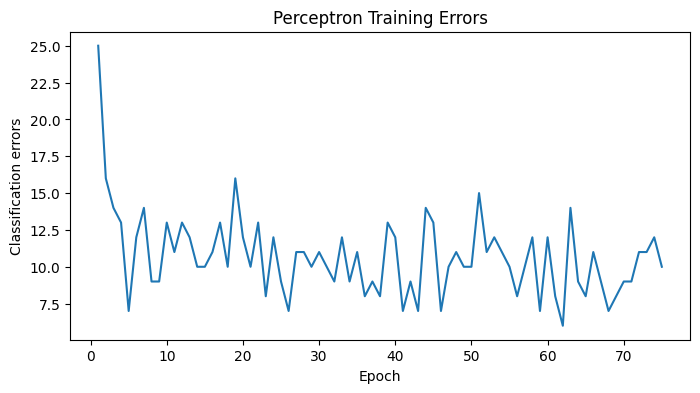

In [32]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(perceptron_errors) + 1), perceptron_errors)
plt.xlabel('Epoch')
plt.ylabel('Classification errors')
plt.title('Perceptron Training Errors')
plt.show()

A single perceptron can learn only a linearly separable boundary. If the error curve reaches zero, the scaled benchmark is linearly separable for this training split; if it plateaus above zero, the remaining errors show the limitation of one linear boundary.

## E2: Activation Functions
The following NumPy functions operate elementwise and are used to visualize common nonlinear activations.

In [33]:
def sigmoid(values):
    """Return elementwise sigmoid activations."""
    return 1 / (1 + np.exp(-values))

def tanh(values):
    """Return elementwise hyperbolic tangent activations."""
    return np.tanh(values)

def relu(values):
    """Return elementwise rectified linear activations."""
    return np.maximum(0, values)

This plot compares sigmoid, tanh, and ReLU over the same input range.

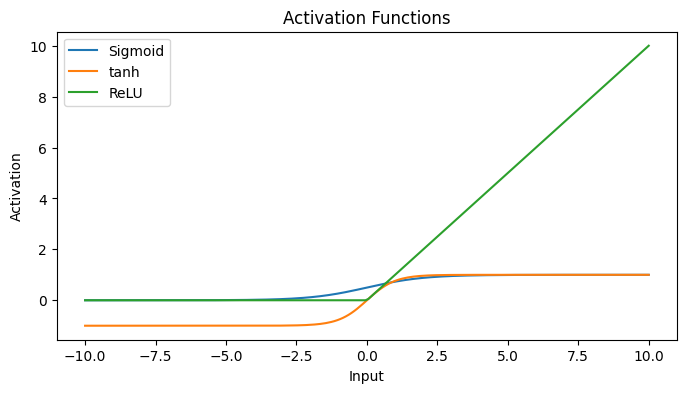

In [34]:
activation_inputs = np.linspace(-10, 10, 200)
plt.figure(figsize=(8, 4))
plt.plot(activation_inputs, sigmoid(activation_inputs), label='Sigmoid')
plt.plot(activation_inputs, tanh(activation_inputs), label='tanh')
plt.plot(activation_inputs, relu(activation_inputs), label='ReLU')
plt.xlabel('Input')
plt.ylabel('Activation')
plt.title('Activation Functions')
plt.legend()
plt.show()

Sigmoid maps to (0, 1), tanh maps to (-1, 1), and ReLU maps to [0, infinity). Sigmoid is common at binary output layers because its probability-like range pairs naturally with binary cross-entropy. ReLU is common in hidden layers because it is cheap, sparse for negative inputs, and avoids vanishing gradients on positive inputs.

This output evaluates the sigmoid derivative at large positive and negative values to demonstrate vanishing gradients.

In [35]:
extreme_inputs = np.array([-10.0, -5.0, 0.0, 5.0, 10.0])
extreme_sigmoid = sigmoid(extreme_inputs)
sigmoid_derivative = extreme_sigmoid * (1 - extreme_sigmoid)
for value, derivative in zip(extreme_inputs, sigmoid_derivative):
    print(f'sigmoid derivative at {value:.0f}: {derivative:.8f}')

sigmoid derivative at -10: 0.00004540
sigmoid derivative at -5: 0.00664806
sigmoid derivative at 0: 0.25000000
sigmoid derivative at 5: 0.00664806
sigmoid derivative at 10: 0.00004540


The derivative is near zero at large absolute inputs, showing why sigmoid can suffer vanishing gradients in deep hidden layers. ReLU retains derivative one for positive inputs, so gradients can propagate more easily there.

## E3: TensorFlow Model
This sequential model has two ReLU hidden layers and a sigmoid output. Adam uses an explicit learning rate of 0.001, and validation uses held-out training data rather than the test set.

In [36]:
tensorflow_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_fit.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])
tensorflow_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
tensorflow_history = tensorflow_model.fit(X_fit, y_fit, validation_data=(X_validation, y_validation), epochs=40, batch_size=32, verbose=0)

These plots show TensorFlow training and validation loss, followed by training and validation accuracy, across epochs.

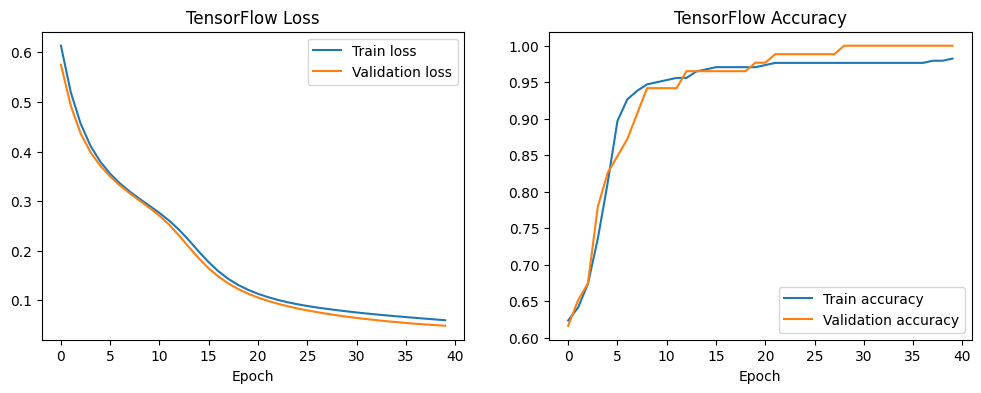

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tensorflow_history.history['loss'], label='Train loss')
axes[0].plot(tensorflow_history.history['val_loss'], label='Validation loss')
axes[0].set_title('TensorFlow Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(tensorflow_history.history['accuracy'], label='Train accuracy')
axes[1].plot(tensorflow_history.history['val_accuracy'], label='Validation accuracy')
axes[1].set_title('TensorFlow Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.show()

The loss and accuracy curves show how the model learns on fit data and generalizes to held-out validation data. Diverging curves would indicate a train-versus-validation generalization gap.

This output evaluates the final TensorFlow model once on the untouched scaled test set.

In [38]:
tensorflow_test_loss, tensorflow_test_accuracy = tensorflow_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'TensorFlow test loss: {tensorflow_test_loss:.4f}')
print(f'TensorFlow test accuracy: {tensorflow_test_accuracy:.4f}')

TensorFlow test loss: 0.1009
TensorFlow test accuracy: 0.9510


The test result measures the final model on previously unseen data. It demonstrates a correct neural-network workflow and is not expected to beat the boosted pipelines from notebook 03.

## E4: PyTorch Model
This comparable PyTorch model uses two ReLU hidden layers and a sigmoid output, so BCELoss is appropriate. The DataLoader batch size is explicitly 32, and Adam uses an explicit learning rate of 0.001.

In [39]:
class TorchBinaryClassifier(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_features, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 1), nn.Sigmoid(),
        )

    def forward(self, features):
        return self.network(features)

torch_X_fit = torch.tensor(X_fit, dtype=torch.float32)
torch_y_fit = torch.tensor(y_fit.reshape(-1, 1), dtype=torch.float32)
torch_X_validation = torch.tensor(X_validation, dtype=torch.float32)
torch_y_validation = torch.tensor(y_validation.reshape(-1, 1), dtype=torch.float32)
torch_train_loader = DataLoader(TensorDataset(torch_X_fit, torch_y_fit), batch_size=32, shuffle=True)
torch_model = TorchBinaryClassifier(X_fit.shape[1])
torch_loss_function = nn.BCELoss()
torch_optimizer = torch.optim.Adam(torch_model.parameters(), lr=0.001)

In [40]:
torch_train_losses = []
torch_validation_losses = []
for _ in range(40):
    torch_model.train()
    batch_losses = []
    for features, targets in torch_train_loader:
        torch_optimizer.zero_grad()
        probabilities = torch_model(features)
        batch_loss = torch_loss_function(probabilities, targets)
        batch_loss.backward()
        torch_optimizer.step()
        batch_losses.append(batch_loss.item())
    torch_train_losses.append(float(np.mean(batch_losses)))
    torch_model.eval()
    with torch.no_grad():
        validation_probabilities = torch_model(torch_X_validation)
        torch_validation_losses.append(torch_loss_function(validation_probabilities, torch_y_validation).item())

This plot compares PyTorch training and validation loss over the same 40-epoch schedule.

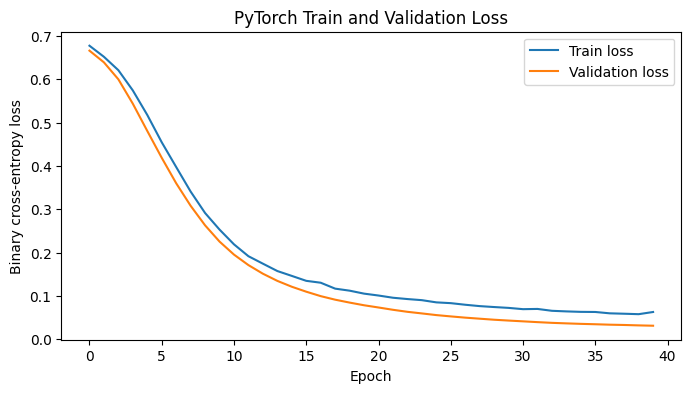

In [41]:
plt.figure(figsize=(8, 4))
plt.plot(torch_train_losses, label='Train loss')
plt.plot(torch_validation_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Binary cross-entropy loss')
plt.title('PyTorch Train and Validation Loss')
plt.legend()
plt.show()

The PyTorch curves provide the same train-versus-validation perspective as TensorFlow, making their learning behavior directly comparable.

This output evaluates PyTorch overfitting signs from the final train and validation losses in both implementations.

In [42]:
tensorflow_overfitting = tensorflow_history.history['val_loss'][-1] > min(tensorflow_history.history['val_loss']) + 0.05
torch_overfitting = torch_validation_losses[-1] > min(torch_validation_losses) + 0.05
print(f'TensorFlow overfitting flag: {tensorflow_overfitting}')
print(f'PyTorch overfitting flag: {torch_overfitting}')

TensorFlow overfitting flag: False
PyTorch overfitting flag: False


The printed flags summarize whether validation loss rose materially above its best value while training continued. A True flag is evidence of the train-loss-down/validation-loss-up pattern of overfitting; False means these runs do not show that material pattern under this simple check.

## Required Discussion

### Forward propagation
Forward propagation passes input features through weighted layers and activations to produce a predicted probability. The TensorFlow sequential model and the PyTorch forward method both perform this transformation before calculating their losses.

### Loss calculation
Loss turns prediction quality into one differentiable scalar objective. Both neural models use binary cross-entropy because their sigmoid outputs represent binary class probabilities.

### Backpropagation
Backpropagation applies the chain rule to compute how each parameter contributed to the loss. TensorFlow performs this internally during fit, while the PyTorch loop invokes it explicitly with loss.backward().

### Gradient
A gradient gives the local direction in which a parameter changes the loss. Optimizers use these derivatives to adjust weights toward lower loss, which is why gradients are produced before each optimizer step.

### Learning rate
The learning rate controls the size of each optimizer update. The explicit 0.001 Adam rate here balances meaningful progress against unstable, overly large updates.

### Epoch
An epoch is one complete pass through the fit data. The 40 epochs shown in both frameworks make the train and validation curves comparable across repeated passes.

### Batch size
Batch size is the number of samples processed before one gradient update. The PyTorch DataLoader and TensorFlow fit call both use batches of 32, which trades noisy updates for practical computational efficiency.

### PyTorch train() versus eval()
train() enables training-mode behavior, including dropout randomness and batch-normalization statistic updates when those layers are present. eval() switches to inference behavior, even though this particular model has neither dropout nor batch normalization, so validation measurements remain conceptually correct.

### MSE versus binary cross-entropy
As in notebook 01, MSE measures squared distance for continuous regression targets. Binary cross-entropy instead penalizes incorrect class probabilities sharply, which matches the sigmoid binary classifiers built in this notebook.

### Signs of overfitting in these curves
The TensorFlow and PyTorch plots should be read by comparing falling training loss with validation loss. The preceding computed flags state whether either observed run shows validation loss rising materially after its best point; that is the concrete overfitting evidence used here.

This notebook stops at deep-learning fundamentals and does not implement Part F transformer fine-tuning or LangChain work.